In [2]:
!pip install imblearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.4 kB 5.8 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report,confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Activation
from tensorflow.keras.utils import to_categorical
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

import seaborn as sns

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Activation
from tensorflow.keras.utils import to_categorical

# Load dataset
data = pd.read_csv('/content/M-CAN Intrusion Dataset1.csv')




In [5]:
data.columns

Index(['CAN ID', 'label', 'DATA[0]', 'DATA[1]', 'DATA[2]', 'DATA[3]',
       'DATA[4]', 'DATA[5]', 'DATA[6]', 'DATA[7]'],
      dtype='object')

In [6]:
data['label'].unique()

array([0., 1.])

In [7]:
data.describe()

,CAN ID,label
count,2.952620e+06,2.952620e+06
mean,9.779915e+02,1.693411e-01
std,6.307052e+02,3.750530e-01
min,0.000000e+00,0.000000e+00
25%,4.660000e+02,0.000000e+00
50%,1.284000e+03,0.000000e+00
75%,1.439000e+03,0.000000e+00
max,4.095000e+03,1.000000e+00


In [8]:
data

,CAN ID,label,DATA[0],DATA[1],DATA[2],DATA[3],DATA[4],DATA[5],DATA[6],DATA[7]
0,290,0.0,7F,00,00,00,00,00,1F,FF
1,829,0.0,00,00,00,00,03,00,00,00
2,1409,0.0,00,00,00,00,00,00,00,00
3,466,0.0,E3,40,00,03,00,00,00,00
4,1393,0.0,7F,00,00,00,00,00,00,00
...,...,...,...,...,...,...,...,...,...,...
2952615,133,0.0,FF,FF,FF,FF,FF,FF,FF,FF
2952616,771,0.0,00,00,10,00,15,00,00,00
2952617,773,0.0,00,00,00,00,00,00,00,00
2952618,772,0.0,00,00,00,00,00,00,00,00


In [9]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import KMeansSMOTE
import pandas as pd

# Splitting the dataset into a 70-30 train-test split
def simple_split(data):
    train_data, test_data = train_test_split(data, test_size=0.3, random_state=42)
    return train_data, test_data

# Assuming 'data' is a Pandas DataFrame
# Apply the splitting function
train_data, test_data = simple_split(data)



X_train = train_data.drop(columns=['label'], errors='ignore')
y_train = train_data['label']



# Recombine X_resampled and y_resampled into a single DataFrame
train_data = pd.concat([pd.DataFrame(X_train, columns=X_train.columns), pd.DataFrame(y_train, columns=['label'])], axis=1)




In [10]:
train_data

,CAN ID,DATA[0],DATA[1],DATA[2],DATA[3],DATA[4],DATA[5],DATA[6],DATA[7],label
1248942,773,00,00,00,00,00,00,00,00,0.0
1562048,1439,00,00,00,00,00,00,00,00,0.0
2743632,1465,00,00,00,00,00,00,00,00,0.0
56763,1468,00,00,00,00,51,7F,F0,00,0.0
2073041,771,00,00,10,00,15,00,00,00,0.0
...,...,...,...,...,...,...,...,...,...,...
1692743,1436,00,00,00,00,00,00,08,F2,0.0
2356330,1438,00,00,00,00,00,00,00,03,0.0
2229084,1408,B6,66,DF,56,01,56,DD,EE,0.0
2768307,468,00,00,04,00,00,00,00,00,0.0


In [11]:
# Convert hexadecimal strings in DATA[0] to DATA[7] columns to integers
data_columns = [f'DATA[{i}]' for i in range(8)]

for col in data_columns:
    # Ensure the value is a string and convert from hex to decimal
    train_data[col] = train_data[col].apply(lambda x: int(str(x), 16) if isinstance(x, str) else x)

# Display the DataFrame
print(train_data)


         CAN ID  DATA[0]  DATA[1]  DATA[2]  DATA[3]  DATA[4]  DATA[5]  \
1248942     773        0        0        0      0.0      0.0      0.0   
1562048    1439        0        0        0      0.0      0.0      0.0   
2743632    1465        0        0        0      0.0      0.0      0.0   
56763      1468        0        0        0      0.0     81.0    127.0   
2073041     771        0        0       16      0.0     21.0      0.0   
...         ...      ...      ...      ...      ...      ...      ...   
1692743    1436        0        0        0      0.0      0.0      0.0   
2356330    1438        0        0        0      0.0      0.0      0.0   
2229084    1408      182      102      223     86.0      1.0     86.0   
2768307     468        0        0        4      0.0      0.0      0.0   
2219110    1438        0        0        0      0.0      0.0      0.0   

         DATA[6]  DATA[7]  label  
1248942      0.0      0.0    0.0  
1562048      0.0      0.0    0.0  
2743632      0.0  

In [12]:


# Remove rows that contain NaN values
train_data = train_data.dropna()

# Display the cleaned DataFrame
print(train_data)


         CAN ID  DATA[0]  DATA[1]  DATA[2]  DATA[3]  DATA[4]  DATA[5]  \
1248942     773        0        0        0      0.0      0.0      0.0   
1562048    1439        0        0        0      0.0      0.0      0.0   
2743632    1465        0        0        0      0.0      0.0      0.0   
56763      1468        0        0        0      0.0     81.0    127.0   
2073041     771        0        0       16      0.0     21.0      0.0   
...         ...      ...      ...      ...      ...      ...      ...   
1692743    1436        0        0        0      0.0      0.0      0.0   
2356330    1438        0        0        0      0.0      0.0      0.0   
2229084    1408      182      102      223     86.0      1.0     86.0   
2768307     468        0        0        4      0.0      0.0      0.0   
2219110    1438        0        0        0      0.0      0.0      0.0   

         DATA[6]  DATA[7]  label  
1248942      0.0      0.0    0.0  
1562048      0.0      0.0    0.0  
2743632      0.0  

In [13]:
# Convert hexadecimal strings in DATA[0] to DATA[7] columns to integers
data_columns = [f'DATA[{i}]' for i in range(8)]

for col in data_columns:
    # Ensure the value is a string and convert from hex to decimal
    test_data[col] = test_data[col].apply(lambda x: int(str(x), 16) if isinstance(x, str) else x)

# Display the DataFrame
print(test_data)

         CAN ID  label  DATA[0]  DATA[1]  DATA[2]  DATA[3]  DATA[4]  DATA[5]  \
2181286    1464    0.0        0        0        0      0.0      0.0      0.0   
1178901       0    1.0        0        0        0      0.0      0.0      0.0   
2097955     384    0.0      251      172      255    199.0    240.0    255.0   
714070      722    0.0        0      176        0      0.0     33.0     64.0   
2172218     290    0.0      127        0        0      0.0      0.0      0.0   
...         ...    ...      ...      ...      ...      ...      ...      ...   
718377     1435    0.0        0        0        0      0.0      0.0      0.0   
2493263    1409    0.0        0        0        0      0.0      0.0      0.0   
2901510    1519    0.0        0        0        0      0.0      0.0      0.0   
1926586    1468    0.0        0        0        0      0.0     81.0    127.0   
1976032    2064    1.0      216      206      109    241.0    126.0    242.0   

         DATA[6]  DATA[7]  
2181286    

In [14]:
# Remove rows that contain NaN values
test_data = test_data.dropna()

# Display the cleaned DataFrame
print(test_data)

         CAN ID  label  DATA[0]  DATA[1]  DATA[2]  DATA[3]  DATA[4]  DATA[5]  \
2181286    1464    0.0        0        0        0      0.0      0.0      0.0   
1178901       0    1.0        0        0        0      0.0      0.0      0.0   
2097955     384    0.0      251      172      255    199.0    240.0    255.0   
714070      722    0.0        0      176        0      0.0     33.0     64.0   
2172218     290    0.0      127        0        0      0.0      0.0      0.0   
...         ...    ...      ...      ...      ...      ...      ...      ...   
1103385    1468    0.0        0        0        0      0.0     81.0    127.0   
718377     1435    0.0        0        0        0      0.0      0.0      0.0   
2493263    1409    0.0        0        0        0      0.0      0.0      0.0   
2901510    1519    0.0        0        0        0      0.0      0.0      0.0   
1926586    1468    0.0        0        0        0      0.0     81.0    127.0   

         DATA[6]  DATA[7]  
2181286    

Echo State Network

In [20]:

# Manual Echo State Network Implementation
class ManualESN:
    def __init__(self, input_dim, reservoir_size, spectral_radius=0.95, sparsity=0.1):
        self.input_dim = input_dim
        self.reservoir_size = reservoir_size
        self.spectral_radius = spectral_radius
        self.sparsity = sparsity
        self.W_in = np.random.uniform(-1, 1, (reservoir_size, input_dim))
        self.W = np.random.uniform(-1, 1, (reservoir_size, reservoir_size))
        self.W[np.random.rand(*self.W.shape) > sparsity] = 0
        max_eig = max(abs(np.linalg.eigvals(self.W)))
        self.W *= spectral_radius / max_eig
        self.state = np.zeros(reservoir_size)

    def update(self, input_data):
        # Convert input_data to a NumPy array with float64 dtype
        input_data = np.array(input_data, dtype=np.float64)
        self.state = np.tanh(np.dot(self.W_in, input_data) + np.dot(self.W, self.state))
        return self.state

    def fit_transform(self, X):
        states = []
        for x in X:
            states.append(self.update(x))
        return np.array(states)


# DNN Training
class ESN_DNN:
    def __init__(self, reservoir_size=200, spectral_radius=0.95):
        self.esn = ManualESN(input_dim=train_data.drop('label', axis=1).shape[1],
                             reservoir_size=reservoir_size, spectral_radius=spectral_radius)
        self.dnn = None

    def train(self, X, y):
        esn_output = self.esn.fit_transform(X)
        self.dnn = Sequential([
            Dense(64, activation='relu', input_shape=(esn_output.shape[1],)),
            Dropout(0.15),
            Dense(64, activation='relu'),
            Dropout(0.15),
            Dense(128, activation='relu'),
            Dropout(0.25),
            Dense(32, activation='relu'),
            Dense(len(np.unique(y)), activation='softmax')
        ])
        self.dnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        self.dnn.fit(esn_output, y, epochs=15, batch_size=64, verbose=1)

    def predict(self, X):
        esn_output = self.esn.fit_transform(X)
        return self.dnn.predict(esn_output)

# Train and evaluate the model
esn_dnn_model = ESN_DNN(reservoir_size=250, spectral_radius=0.95)
esn_dnn_model.train(train_data.drop('label', axis=1).values, train_data['label'].values)




Epoch 1/15
9112/9112 [==============================] - 20s 2ms/step - loss: 0.0191 - accuracy: 0.9951
Epoch 2/15
9112/9112 [==============================] - 20s 2ms/step - loss: 0.0119 - accuracy: 0.9975
Epoch 3/15
9112/9112 [==============================] - 20s 2ms/step - loss: 0.0109 - accuracy: 0.9981
Epoch 4/15
9112/9112 [==============================] - 20s 2ms/step - loss: 0.0108 - accuracy: 0.9981
Epoch 5/15
9112/9112 [==============================] - 20s 2ms/step - loss: 0.0095 - accuracy: 0.9984
Epoch 6/15
9112/9112 [==============================] - 20s 2ms/step - loss: 0.0095 - accuracy: 0.9984
Epoch 7/15
9112/9112 [==============================] - 20s 2ms/step - loss: 0.0092 - accuracy: 0.9985
Epoch 8/15
9112/9112 [==============================] - 20s 2ms/step - loss: 0.0091 - accuracy: 0.9985
Epoch 9/15
9112/9112 [==============================] - 19s 2ms/step - loss: 0.0088 - accuracy: 0.9985
Epoch 10/15
9112/9112 [==============================] - 19s 2ms/step - l

26902/26902 [==============================] - 32s 1ms/step
Classification Report:

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    735778
         1.0       1.00      1.00      1.00    125082

    accuracy                           1.00    860860
   macro avg       1.00      1.00      1.00    860860
weighted avg       1.00      1.00      1.00    860860



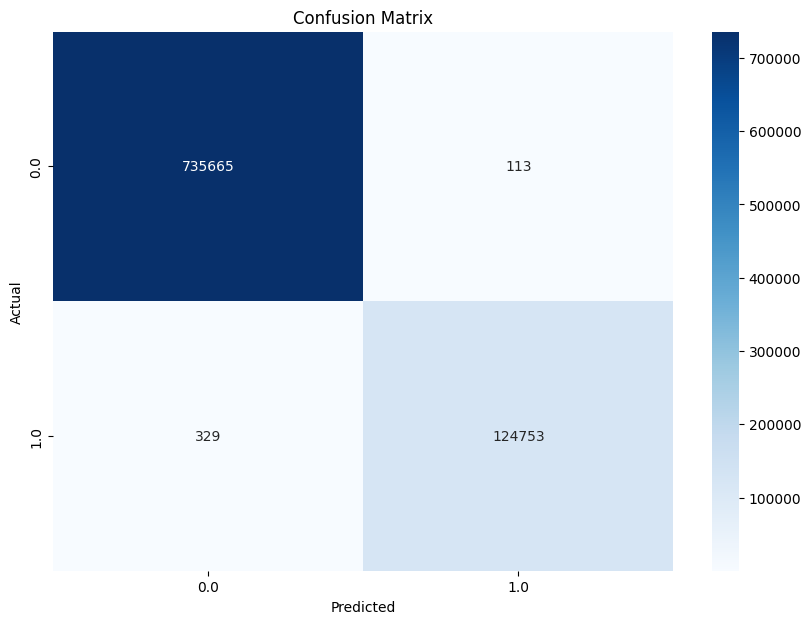

In [21]:
# Prediction
y_pred = esn_dnn_model.predict(test_data.drop('label', axis=1).values)
y_pred = np.argmax(y_pred, axis=1)

# Evaluation
print("Classification Report:\n")
print(classification_report(test_data['label'].values, y_pred))

# Plot classification report
conf_matrix = confusion_matrix(test_data['label'].values, y_pred)
plt.figure(figsize=(10, 7))
plt.title("Confusion Matrix")
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(test_data['label']),
            yticklabels=np.unique(test_data['label']))
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

18223/18223 [==============================] - 21s 1ms/step
Test Data Metrics:
Accuracy: 0.9995
Precision: 0.9993
Recall: 0.9986
F1 Score: 0.9990
AUC-ROC: 0.9996

Train Data Metrics:
Accuracy: 0.9987
Precision: 0.9987
Recall: 0.9987
F1 Score: 0.9987
AUC-ROC: 0.9997

Classification Report for Test Data:

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    735778
         1.0       1.00      1.00      1.00    125082

    accuracy                           1.00    860860
   macro avg       1.00      1.00      1.00    860860
weighted avg       1.00      1.00      1.00    860860



KeyError: 'Category'

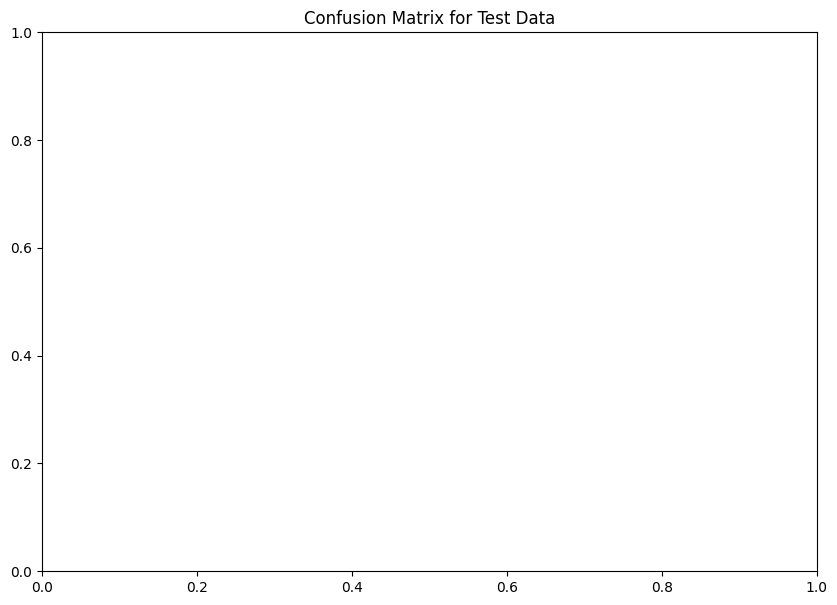

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prediction for Test Data
y_test_true = test_data['label'].values
y_test_pred_prob = esn_dnn_model.predict(test_data.drop('label', axis=1).values)
y_test_pred = np.argmax(y_test_pred_prob, axis=1)

# Prediction for Train Data
y_train_true = train_data['label'].values
y_train_pred_prob = esn_dnn_model.predict(train_data.drop('label', axis=1).values)
y_train_pred = np.argmax(y_train_pred_prob, axis=1)

def evaluate_metrics(y_true, y_pred, y_pred_prob, average='macro'):
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average=average, zero_division=0),
        "Recall": recall_score(y_true, y_pred, average=average),
        "F1 Score": f1_score(y_true, y_pred, average=average),
        # Select the probability for the positive class (class 1)
        "AUC-ROC": roc_auc_score(y_true, y_pred_prob[:, 1], multi_class='ovr')
    }
    return metrics


# Evaluate for Test Data
test_metrics = evaluate_metrics(y_test_true, y_test_pred, y_test_pred_prob)
print("Test Data Metrics:")
for key, value in test_metrics.items():
    print(f"{key}: {value:.4f}")

# Evaluate for Train Data
train_metrics = evaluate_metrics(y_train_true, y_train_pred, y_train_pred_prob)
print("\nTrain Data Metrics:")
for key, value in train_metrics.items():
    print(f"{key}: {value:.4f}")

# Classification Report
print("\nClassification Report for Test Data:\n")
print(classification_report(y_test_true, y_test_pred))






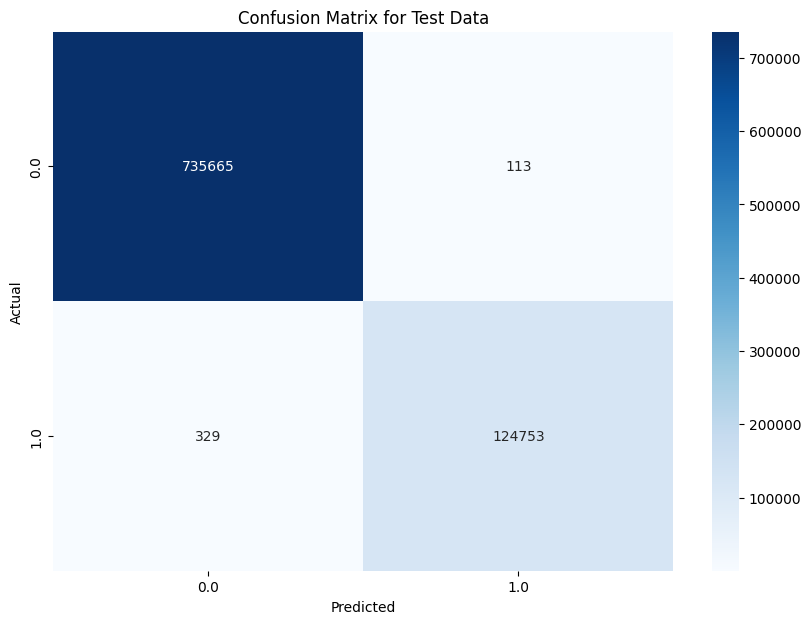

In [23]:
# Confusion Matrix for Test Data
conf_matrix = confusion_matrix(y_test_true, y_test_pred)
plt.figure(figsize=(10, 7))
plt.title("Confusion Matrix for Test Data")
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(test_data['label']),
            yticklabels=np.unique(test_data['label']))
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()